2025-01-09 14:53:31.833138: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-01-09 14:53:32.647209: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


Connected to the database.
Lade Daten aus der 'canvassamples'-Collection...
2004832 Dokumente aus 'canvassamples' geladen.
Lade Daten aus der 'fingerprints'-Collection...
21 Dokumente aus 'fingerprints' geladen.
Verarbeite Benutzer benutzername_1...
Datenaufteilung für Benutzer benutzername_1 abgeschlossen.
Verarbeite Benutzer benutzername_3...
Datenaufteilung für Benutzer benutzername_3 abgeschlossen.
Verarbeite Benutzer benutzername_4...
Datenaufteilung für Benutzer benutzername_4 abgeschlossen.
Verarbeite Benutzer benutzername_5...
Datenaufteilung für Benutzer benutzername_5 abgeschlossen.
Verarbeite Benutzer benutzername_6...
Datenaufteilung für Benutzer benutzername_6 abgeschlossen.
Verarbeite Benutzer benutzername_7...
Datenaufteilung für Benutzer benutzername_7 abgeschlossen.
Verarbeite Benutzer benutzername_8...
Datenaufteilung für Benutzer benutzername_8 abgeschlossen.
Verarbeite Benutzer benutzername_9...
Datenaufteilung für Benutzer benutzername_9 abgeschlossen.
Verarbeite B

2025-01-09 14:57:55.101174: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:995] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2025-01-09 14:57:55.274555: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:995] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2025-01-09 14:57:55.274858: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:995] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysf

2188/2188 [==============================] - 29s 12ms/step - loss: 0.0312 - val_loss: 0.0294
Epoch 2/50
2188/2188 [==============================] - 27s 12ms/step - loss: 0.0268 - val_loss: 0.0269
Epoch 3/50
2188/2188 [==============================] - 27s 13ms/step - loss: 0.0256 - val_loss: 0.0254
Epoch 4/50
2188/2188 [==============================] - 27s 12ms/step - loss: 0.0248 - val_loss: 0.0251
Epoch 5/50
2188/2188 [==============================] - 27s 12ms/step - loss: 0.0243 - val_loss: 0.0251
Epoch 6/50
2188/2188 [==============================] - 27s 13ms/step - loss: 0.0240 - val_loss: 0.0249
Epoch 7/50
2188/2188 [==============================] - 27s 12ms/step - loss: 0.0237 - val_loss: 0.0246
Epoch 8/50
2188/2188 [==============================] - 28s 13ms/step - loss: 0.0234 - val_loss: 0.0243
Epoch 9/50
2188/2188 [==============================] - 27s 12ms/step - loss: 0.0232 - val_loss: 0.0245
Epoch 10/50
2188/2188 [==============================] - 28s 13ms/step - lo

/usr/local/lib/python3.8/dist-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


1/1 [==============================] - 0s 13ms/step


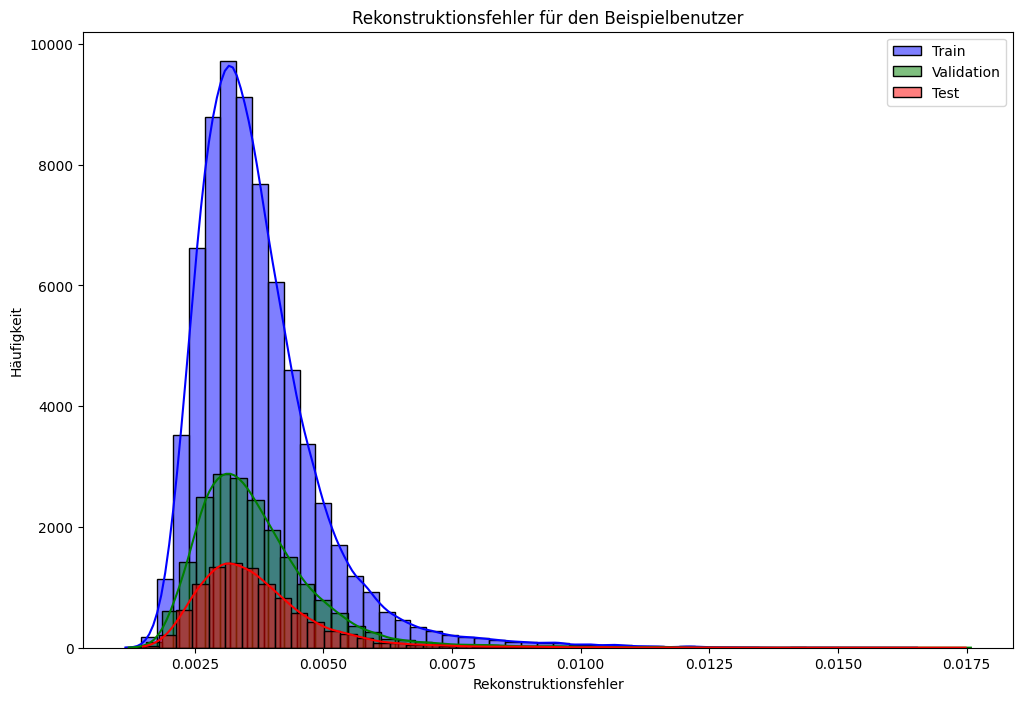

1/1 [==============================] - 0s 11ms/step


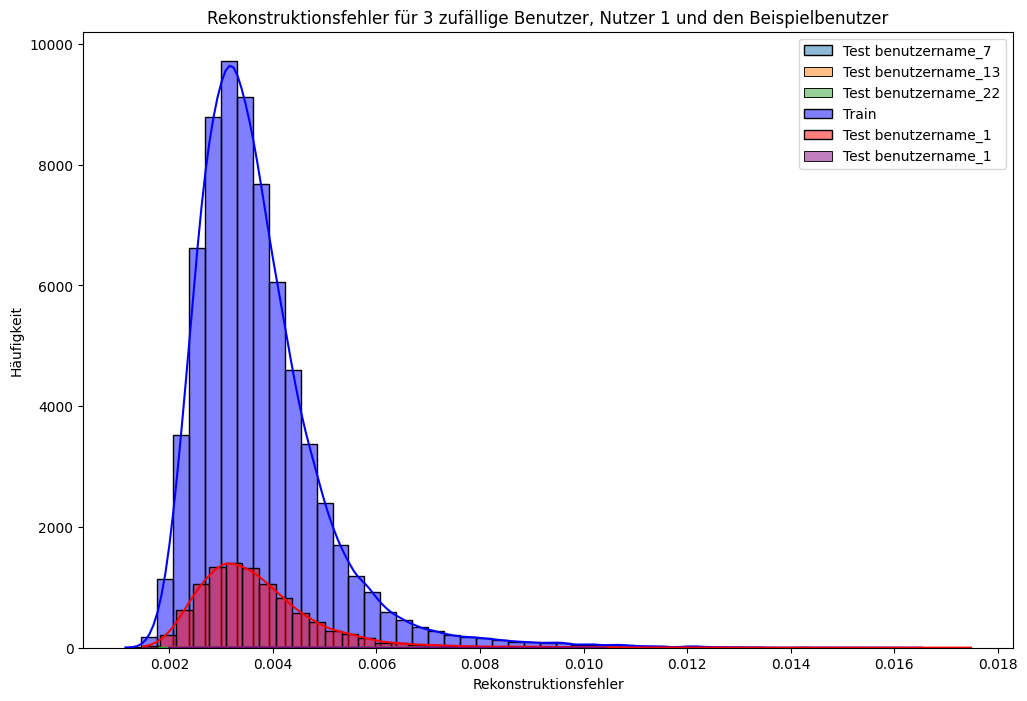

Rekonstruktionsfehler für den Trainingssatz:
count    70000.000000
mean         0.003713
std          0.001238
min          0.001152
25%          0.002907
50%          0.003471
75%          0.004211
max          0.016533
dtype: float64
Rekonstruktionsfehler für den Validierungssatz:
count    20001.000000
mean         0.003704
std          0.001221
min          0.001217
25%          0.002900
50%          0.003470
75%          0.004215
max          0.017582
dtype: float64
Rekonstruktionsfehler für den Testsatz:
count    9999.000000
mean        0.003721
std         0.001250
min         0.001493
25%         0.002918
50%         0.003488
75%         0.004209
max         0.017479
dtype: float64
Rekonstruktionsfehler für den Testsatz von Benutzer benutzername_7:
count    100.000000
mean       0.004128
std        0.001308
min        0.002341
25%        0.003147
50%        0.003873
75%        0.004644
max        0.010768
dtype: float64
Rekonstruktionsfehler für den Testsatz von Benutzer benutze

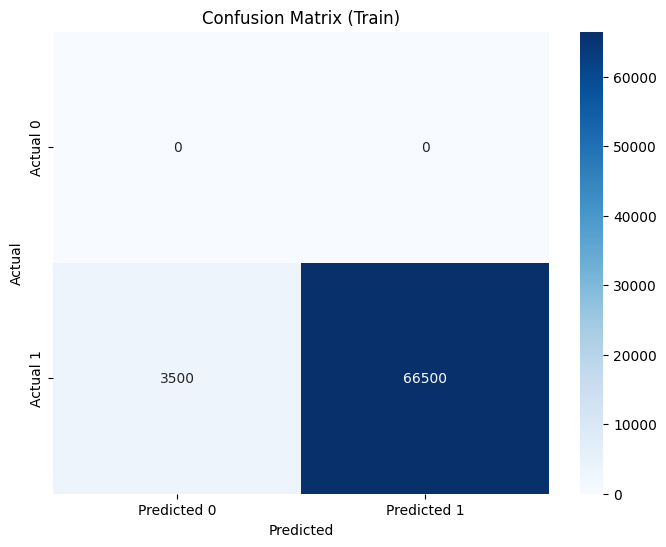

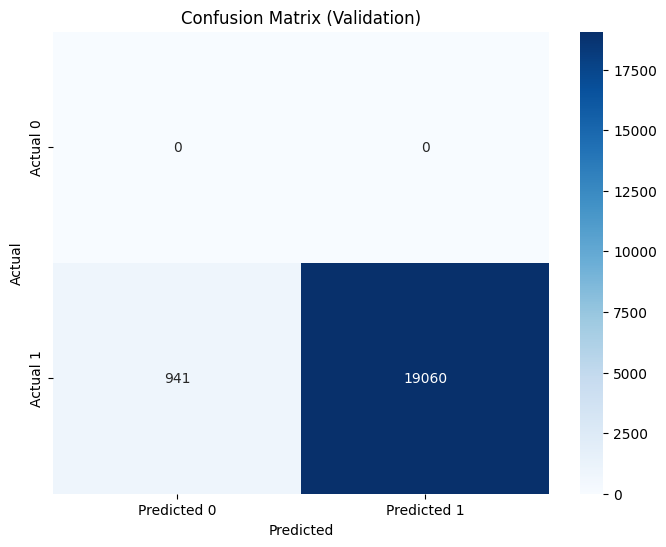

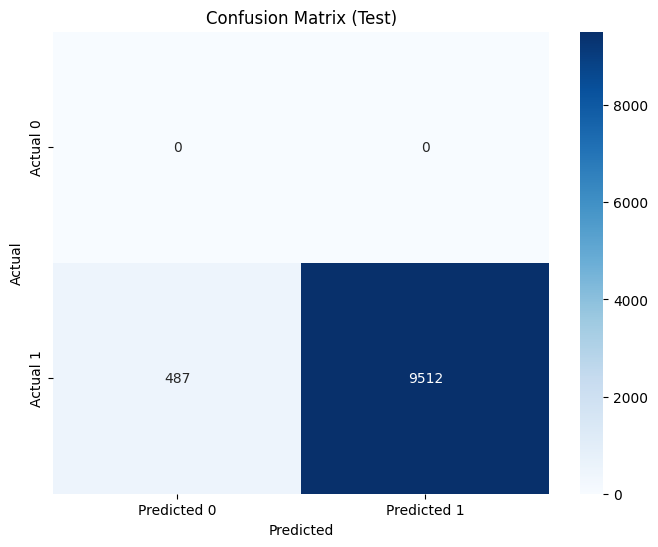

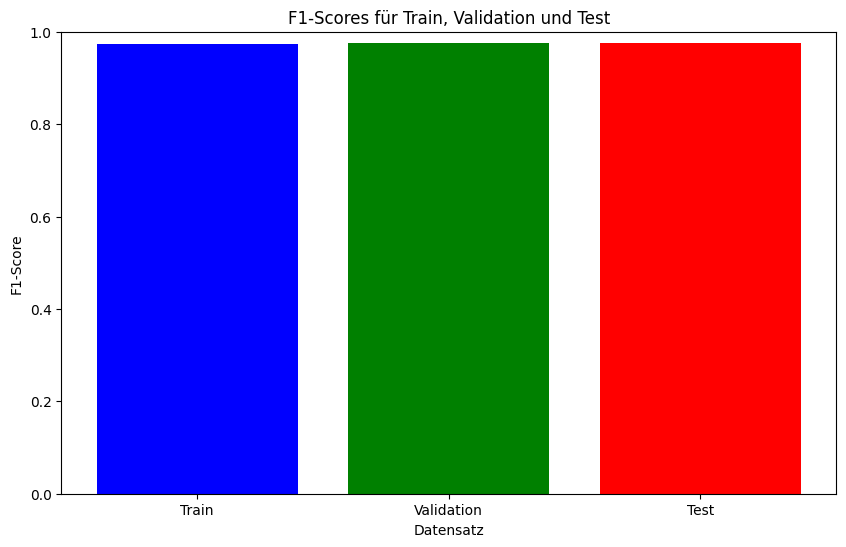

In [2]:
import os
import pandas as pd
import pymongo
import matplotlib.pyplot as plt
import seaborn as sns
import base64
from io import BytesIO
from PIL import Image
import numpy as np
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import Sequence
from sklearn.metrics import f1_score, confusion_matrix
import gc

def connect_to_database():
    try:
        mongo_uri = os.getenv('MONGO_URI', 'mongodb://localhost:27017/fingerprintDB')
        client = pymongo.MongoClient(mongo_uri)
        db = client.get_default_database()
        print("Connected to the database.")
        return db
    except pymongo.errors.ConnectionError as err:
        print(f"Error: {err}")
        return None

# Verbindung zur Datenbank herstellen
db = connect_to_database()
if db is None:
    print("Failed to connect to the database. Exiting...")
    exit()

# Daten aus der 'canvassamples'-Collection laden
print("Lade Daten aus der 'canvassamples'-Collection...")
canvassamples_collection = db['canvassamples']
canvassamples_cursor = canvassamples_collection.find()
canvassamples_data = list(canvassamples_cursor)
canvassamples_df = pd.DataFrame(canvassamples_data)
print(f"{len(canvassamples_data)} Dokumente aus 'canvassamples' geladen.")

# Daten aus der 'fingerprints'-Collection laden
print("Lade Daten aus der 'fingerprints'-Collection...")
fingerprints_collection = db['fingerprints']
fingerprints_cursor = fingerprints_collection.find()
fingerprints_data = list(fingerprints_cursor)
fingerprints_df = pd.DataFrame(fingerprints_data)
print(f"{len(fingerprints_data)} Dokumente aus 'fingerprints' geladen.")

# Daten zusammenführen
merged_df = pd.merge(canvassamples_df, fingerprints_df, left_on='fingerprintId', right_on='_id', suffixes=('_sample', '_fingerprint'))

# Benutzer-IDs extrahieren
user_ids = merged_df['username'].unique()

# DataFrames für jeden Benutzer erstellen
user_dfs = {user_id: merged_df[merged_df['username'] == user_id] for user_id in user_ids}

def process_sample(base64_str, target_size):
    try:
        image_data = base64.b64decode(base64_str)
        image = Image.open(BytesIO(image_data)).convert('RGB')
        image = image.resize(target_size)
        return np.array(image) / 255.0
    except Exception as e:
        print(f"Fehler beim Dekodieren des Bildes: {e}")
        return None

def split_data_indices(df):
    if len(df) < 3:
        raise ValueError("Nicht genügend Samples zum Aufteilen.")
    indices = df.index.values
    X_train_indices, X_temp_indices = train_test_split(indices, test_size=0.3, random_state=42)
    X_val_indices, X_test_indices = train_test_split(X_temp_indices, test_size=0.3333, random_state=42)
    return X_train_indices, X_val_indices, X_test_indices

class DataGenerator(Sequence):
    def __init__(self, df, indices, target_size, batch_size=32):
        self.df = df
        self.indices = indices
        self.target_size = target_size
        self.batch_size = batch_size

    def __len__(self):
        return int(np.ceil(len(self.indices) / self.batch_size))

    def __getitem__(self, idx):
        batch_indices = self.indices[idx * self.batch_size:(idx + 1) * self.batch_size]
        batch_samples = [process_sample(self.df.at[i, 'sampleData'], self.target_size) for i in batch_indices]
        batch_samples = [sample for sample in batch_samples if sample is not None]  # Remove None entries
        batch_samples = np.array(batch_samples)
        batch_samples = batch_samples.reshape((batch_samples.shape[0], -1))  # Flatten for the Dense encoder
        return batch_samples, batch_samples  # Input und Output sind gleich für Autoencoder

target_size = (64, 64)  # Zielgröße der Bilder

user_generators = {}
for user_id, df in user_dfs.items():
    print(f"Verarbeite Benutzer {user_id}...")
    try:
        X_train_indices, X_val_indices, X_test_indices = split_data_indices(df)
        train_generator = DataGenerator(df, X_train_indices, target_size, batch_size=32)
        val_generator = DataGenerator(df, X_val_indices, target_size, batch_size=32)
        test_generator = DataGenerator(df, X_test_indices, target_size, batch_size=32)
        user_generators[user_id] = (train_generator, val_generator, test_generator)
        print(f"Datenaufteilung für Benutzer {user_id} abgeschlossen.")
    except Exception as e:
        print(f"Fehler bei der Datenaufteilung für Benutzer {user_id}: {e}")
print("Datenaufteilung für alle Benutzer abgeschlossen.")

# Funktion zur Erstellung des Autoencoders
def create_autoencoder(input_dim):
    input_layer = Input(shape=(input_dim,))
    encoder = Dense(128, activation="relu")(input_layer)
    encoder = Dropout(0.3)(encoder)
    encoder = Dense(64, activation="relu")(encoder)
    encoder = Dense(32, activation="relu")(encoder)
    decoder = Dense(64, activation="relu")(encoder)
    decoder = Dense(128, activation="relu")(decoder)
    decoder = Dense(input_dim, activation="sigmoid")(decoder)
    autoencoder = Model(inputs=input_layer, outputs=decoder)
    autoencoder.compile(optimizer=Adam(), loss='mae')
    return autoencoder

# Verzeichnis für Modelle erstellen
model_dir = "Modelle/Autoencoder"
os.makedirs(model_dir, exist_ok=True)

# Beispielhafter Benutzer
example_user_id = next(iter(user_generators))
train_generator, val_generator, test_generator = user_generators[example_user_id]

# Eingabeform
for batch in train_generator:
    input_dim = batch[0].shape[1]
    break

# Modell erstellen
autoencoder = create_autoencoder(input_dim)

# Modell trainieren
autoencoder.fit(
    train_generator,
    epochs=50,
    validation_data=val_generator
)

# Modell speichern
model_path = os.path.join(model_dir, "autoencoder_model.h5")
autoencoder.save(model_path)
print(f"Modell gespeichert unter: {model_path}")

# Berechnung der Rekonstruktionsfehler
def calculate_reconstruction_error(model, generator):
    reconstruction_errors = []
    for batch in generator:
        X, _ = batch
        reconstructed = model.predict(X)
        reconstruction_error = np.mean(np.square(X - reconstructed), axis=1)
        reconstruction_errors.extend(reconstruction_error)
    return np.array(reconstruction_errors)

# Rekonstruktionsfehler für den Trainings-, Validierungs- und Test-Satz des Benutzers
reconstruction_error_train = calculate_reconstruction_error(autoencoder, train_generator)
reconstruction_error_val = calculate_reconstruction_error(autoencoder, val_generator)
reconstruction_error_test = calculate_reconstruction_error(autoencoder, test_generator)

# Grafische Darstellung der Ergebnisse für den Beispielbenutzer
plt.figure(figsize=(12, 8))
sns.histplot(reconstruction_error_train, bins=50, kde=True, color='blue', label='Train')
sns.histplot(reconstruction_error_val, bins=50, kde=True, color='green', label='Validation')
sns.histplot(reconstruction_error_test, bins=50, kde=True, color='red', label='Test')

plt.title('Rekonstruktionsfehler für den Beispielbenutzer')
plt.xlabel('Rekonstruktionsfehler')
plt.ylabel('Häufigkeit')
plt.legend()
plt.show()

# Berechnung der Rekonstruktionsfehler für eine begrenzte Anzahl von Testdaten
def calculate_reconstruction_error_limited(model, generator, limit=100):
    reconstruction_errors = []
    count = 0
    for batch in generator:
        if count >= limit:
            break
        X, _ = batch
        reconstructed = model.predict(X)
        reconstruction_error = np.mean(np.square(X - reconstructed), axis=1)
        reconstruction_errors.extend(reconstruction_error)
        count += len(X)
    return np.array(reconstruction_errors[:limit])

# Rekonstruktionsfehler für die Test-Sätze von 3 zufälligen Benutzern
import random
random_user_errors = {}
sampled_user_ids = random.sample([uid for uid in user_ids if uid != example_user_id], 3)
for other_user_id in sampled_user_ids:
    _, _, test_generator_other = user_generators[other_user_id]
    random_user_errors[other_user_id] = calculate_reconstruction_error_limited(autoencoder, test_generator_other, limit=100)

# Rekonstruktionsfehler für Nutzer 1
user_1_id = user_ids[0]  # Assuming user 1 is the first user in the list
_, _, test_generator_user_1 = user_generators[user_1_id]
reconstruction_error_user_1 = calculate_reconstruction_error_limited(autoencoder, test_generator_user_1, limit=100)

# Grafische Darstellung der Ergebnisse für 3 zufällige Benutzer und Nutzer 1
plt.figure(figsize=(12, 8))
for other_user_id, errors in random_user_errors.items():
    sns.histplot(errors, bins=50, kde=True, label=f'Test {other_user_id}')

# Hinzufügen der Rekonstruktionsfehler des Beispielbenutzers und Nutzer 1 zum Vergleich
sns.histplot(reconstruction_error_train, bins=50, kde=True, color='blue', label='Train')
sns.histplot(reconstruction_error_test, bins=50, kde=True, color='red', label=f'Test {example_user_id}')
sns.histplot(reconstruction_error_user_1, bins=50, kde=True, color='purple', label=f'Test {user_1_id}')

plt.title('Rekonstruktionsfehler für 3 zufällige Benutzer, Nutzer 1 und den Beispielbenutzer')
plt.xlabel('Rekonstruktionsfehler')
plt.ylabel('Häufigkeit')
plt.legend()
plt.show()

# Zusammenfassung der Ergebnisse für den Beispielbenutzer
print("Rekonstruktionsfehler für den Trainingssatz:")
print(pd.Series(reconstruction_error_train).describe())

print("Rekonstruktionsfehler für den Validierungssatz:")
print(pd.Series(reconstruction_error_val).describe())

print("Rekonstruktionsfehler für den Testsatz:")
print(pd.Series(reconstruction_error_test).describe())

# Zusammenfassung der Ergebnisse für 3 zufällige Benutzer und Nutzer 1
for other_user_id, errors in random_user_errors.items():
    print(f"Rekonstruktionsfehler für den Testsatz von Benutzer {other_user_id}:")
    print(pd.Series(errors).describe())

print(f"Rekonstruktionsfehler für den Testsatz von Benutzer {user_1_id}:")
print(pd.Series(reconstruction_error_user_1).describe())

# Bewertung der Modellleistung
mean_train_error = np.mean(reconstruction_error_train)
mean_val_error = np.mean(reconstruction_error_val)
mean_test_error = np.mean(reconstruction_error_test)
mean_other_user_errors = {user_id: np.mean(errors) for user_id, errors in random_user_errors.items()}
mean_user_1_error = np.mean(reconstruction_error_user_1)

print("\nBewertung der Modellleistung:")
print(f"Durchschnittlicher Rekonstruktionsfehler (Train): {mean_train_error}")
print(f"Durchschnittlicher Rekonstruktionsfehler (Validation): {mean_val_error}")
print(f"Durchschnittlicher Rekonstruktionsfehler (Test): {mean_test_error}")

for user_id, mean_error in mean_other_user_errors.items():
    print(f"Durchschnittlicher Rekonstruktionsfehler (Test {user_id}): {mean_error}")

print(f"Durchschnittlicher Rekonstruktionsfehler (Test {user_1_id}): {mean_user_1_error}")

# Adaptive Erklärung der Ergebnisse
print("\nAdaptive Erklärung der Ergebnisse:")
if mean_test_error < min(mean_other_user_errors.values()):
    print("Das Modell erkennt den gleichen Benutzer gut und unterscheidet ihn von anderen Benutzern.")
elif mean_test_error < np.mean(list(mean_other_user_errors.values())):
    print("Das Modell erkennt den gleichen Benutzer einigermaßen gut, aber es gibt Raum für Verbesserungen.")
else:
    print("Das Modell hat Schwierigkeiten, den gleichen Benutzer von anderen Benutzern zu unterscheiden. Eine weitere Optimierung ist erforderlich.")

# Berechnung der F1-Scores und Konfusionsmatrix
def calculate_f1_and_confusion_matrix(model, generator, threshold):
    y_true = []
    y_pred = []
    for batch in generator:
        X, _ = batch
        reconstructed = model.predict(X)
        reconstruction_error = np.mean(np.square(X - reconstructed), axis=1)
        y_true.extend([1] * len(reconstruction_error))  # Alle echten Labels sind 1 (positiv)
        y_pred.extend([1 if error < threshold else 0 for error in reconstruction_error])
    return f1_score(y_true, y_pred), confusion_matrix(y_true, y_pred)

# Schwellenwert für Rekonstruktionsfehler festlegen
threshold = np.percentile(reconstruction_error_train, 95)

# F1-Score und Konfusionsmatrix für den Beispielbenutzer
f1_train, cm_train = calculate_f1_and_confusion_matrix(autoencoder, train_generator, threshold)
f1_val, cm_val = calculate_f1_and_confusion_matrix(autoencoder, val_generator, threshold)
f1_test, cm_test = calculate_f1_and_confusion_matrix(autoencoder, test_generator, threshold)

print(f"F1-Score (Train): {f1_train}")
print(f"F1-Score (Validation): {f1_val}")
print(f"F1-Score (Test): {f1_test}")

# Konfusionsmatrix plotten
def plot_confusion_matrix(cm, title):
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Predicted 0', 'Predicted 1'], yticklabels=['Actual 0', 'Actual 1'])
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(title)
    plt.show()

plot_confusion_matrix(cm_train, 'Confusion Matrix (Train)')
plot_confusion_matrix(cm_val, 'Confusion Matrix (Validation)')
plot_confusion_matrix(cm_test, 'Confusion Matrix (Test)')

# F1-Scores grafisch darstellen
f1_scores = {
    'Train': f1_train,
    'Validation': f1_val,
    'Test': f1_test
}

plt.figure(figsize=(10, 6))
plt.bar(f1_scores.keys(), f1_scores.values(), color=['blue', 'green', 'red'])
plt.title('F1-Scores für Train, Validation und Test')
plt.xlabel('Datensatz')
plt.ylabel('F1-Score')
plt.ylim(0, 1)
plt.show()

1/1 [==============================] - 0s 11ms/step


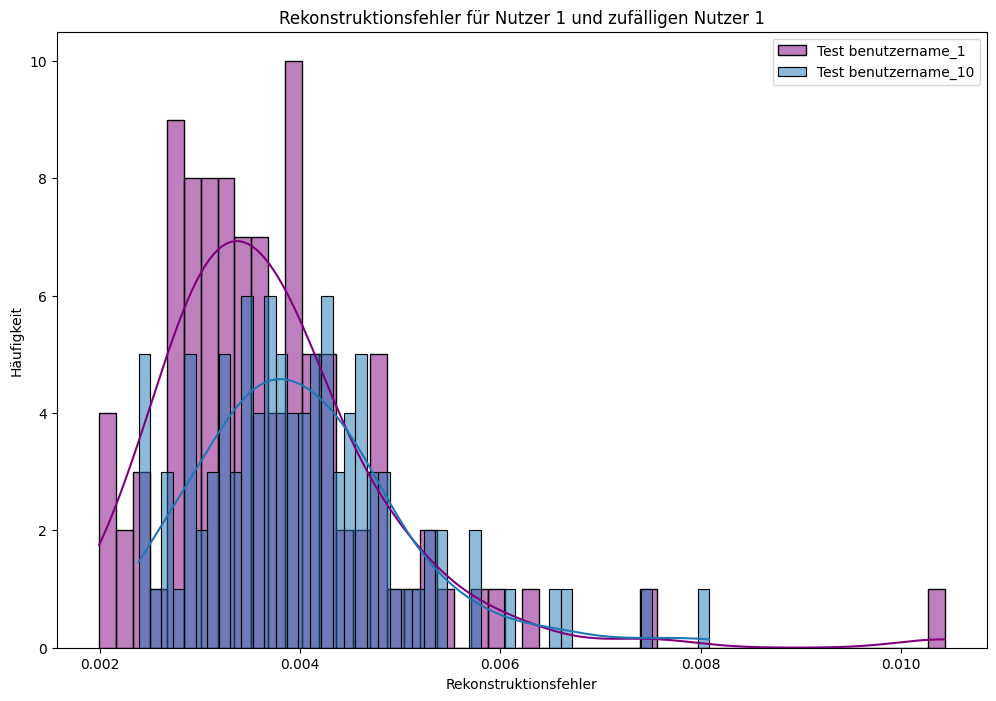

1/1 [==============================] - 0s 12ms/step


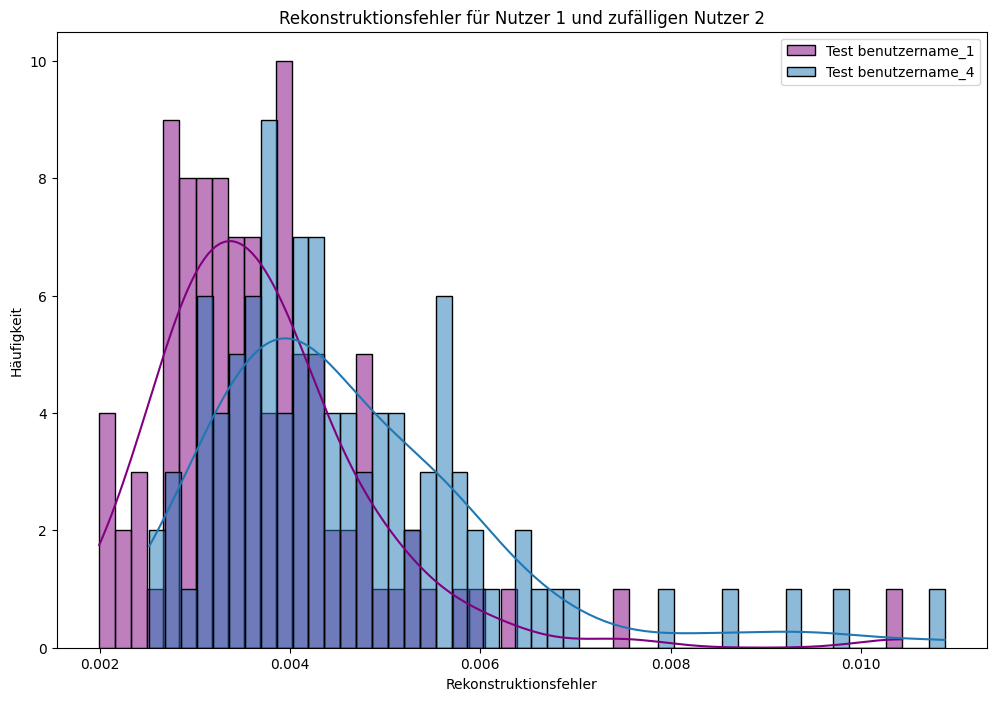

1/1 [==============================] - 0s 12ms/step


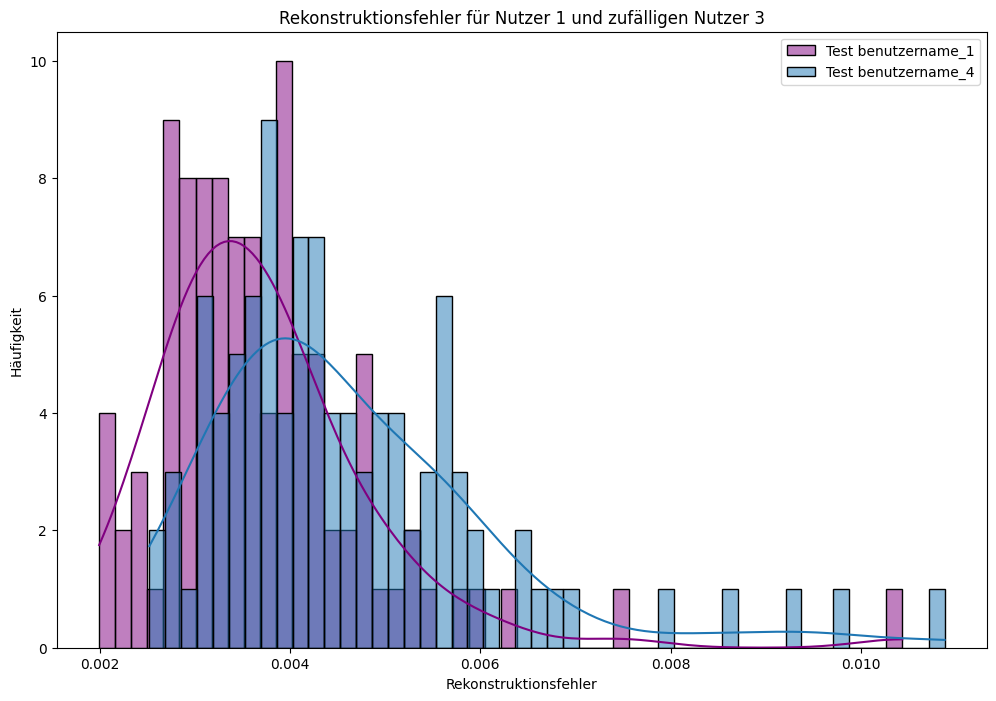

1/1 [==============================] - 0s 14ms/step


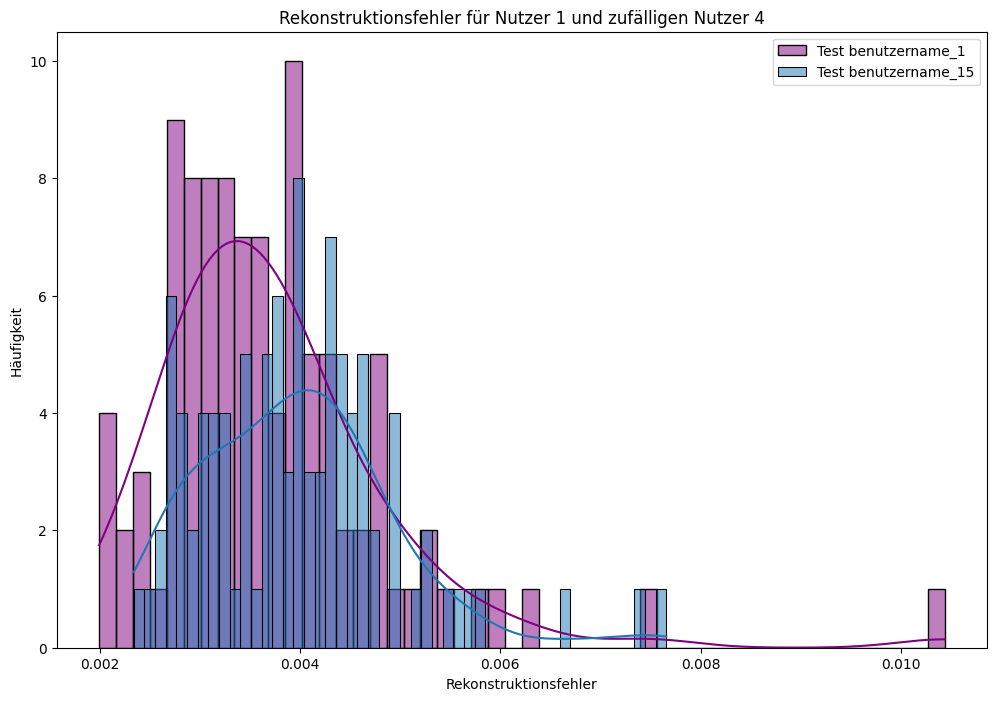

1/1 [==============================] - 0s 12ms/step


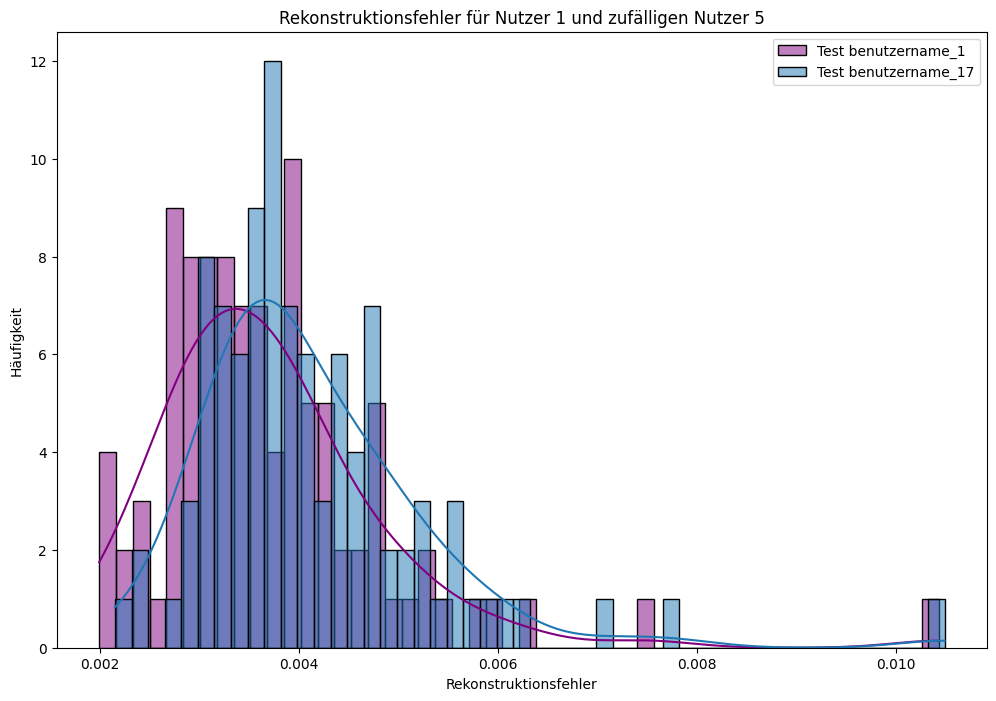

1/1 [==============================] - 0s 12ms/step

Bewertung der Modellleistung:
Durchschnittlicher Rekonstruktionsfehler (Nutzer 1): 0.0037173280473902447
Durchschnittlicher Rekonstruktionsfehler (zufällige Nutzer): 0.0041308400291724485

Adaptive Erklärung der Ergebnisse:
Das Modell erkennt Nutzer 1 einigermaßen gut, aber es gibt Raum für Verbesserungen.
63/63 [==============================] - 0s 956us/step
Anzahl der zufälligen Samples: 2000
Rekonstruktionsfehler für zufällige Samples: [0.00565378 0.0042415  0.00642083 ... 0.0025752  0.00481737 0.0040196 ]


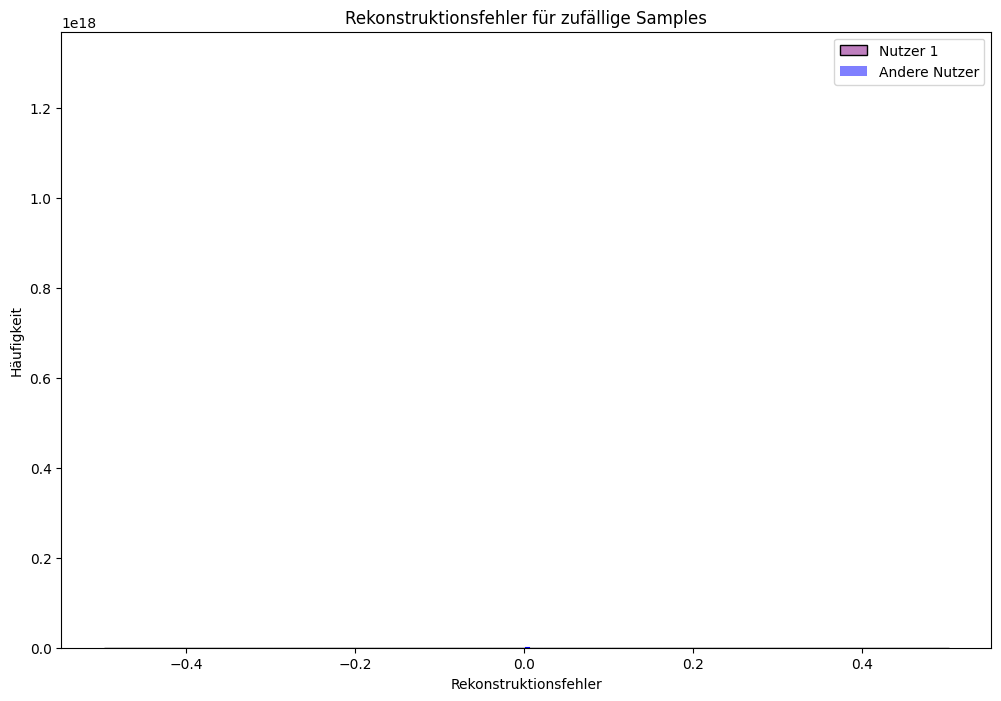


Bewertung der Modellleistung für zufällige Samples:
Durchschnittlicher Rekonstruktionsfehler (Nutzer 1 Samples): 0.0027029076364193574
Durchschnittlicher Rekonstruktionsfehler (Andere Nutzer Samples): 0.0038792960717719854

Adaptive Erklärung der Ergebnisse für zufällige Samples:
Das Modell erkennt zufällige Samples von Nutzer 1 gut und unterscheidet sie von anderen Nutzern.


In [3]:
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Berechnung der Rekonstruktionsfehler
def calculate_reconstruction_error(model, generator):
    reconstruction_errors = []
    for batch in generator:
        X, _ = batch
        reconstructed = model.predict(X)
        reconstruction_error = np.mean(np.square(X - reconstructed), axis=1)
        reconstruction_errors.extend(reconstruction_error)
    return np.array(reconstruction_errors)

# Berechnung der Rekonstruktionsfehler für eine begrenzte Anzahl von Testdaten
def calculate_reconstruction_error_limited(model, generator, limit=100):
    reconstruction_errors = []
    count = 0
    for batch in generator:
        if count >= limit:
            break
        X, _ = batch
        reconstructed = model.predict(X)
        reconstruction_error = np.mean(np.square(X - reconstructed), axis=1)
        reconstruction_errors.extend(reconstruction_error)
        count += len(X)
    return np.array(reconstruction_errors[:limit])

# Rekonstruktionsfehler für Nutzer 1
user_1_id = user_ids[0]  # Assuming user 1 is the first user in the list
_, _, test_generator_user_1 = user_generators[user_1_id]
reconstruction_error_user_1 = calculate_reconstruction_error_limited(autoencoder, test_generator_user_1, limit=100)

# Erstellen von 5 Diagrammen mit Nutzer 1 und einem zufälligen anderen Nutzer
for i in range(5):
    random_user_id = random.choice([uid for uid in user_ids if uid != user_1_id])
    _, _, test_generator_random_user = user_generators[random_user_id]
    reconstruction_error_random_user = calculate_reconstruction_error_limited(autoencoder, test_generator_random_user, limit=100)
    
    plt.figure(figsize=(12, 8))
    sns.histplot(reconstruction_error_user_1, bins=50, kde=True, color='purple', label=f'Test {user_1_id}')
    sns.histplot(reconstruction_error_random_user, bins=50, kde=True, label=f'Test {random_user_id}')
    
    plt.title(f'Rekonstruktionsfehler für Nutzer 1 und zufälligen Nutzer {i+1}')
    plt.xlabel('Rekonstruktionsfehler')
    plt.ylabel('Häufigkeit')
    plt.legend()
    plt.show()

# Bewertung der Modellleistung
mean_user_1_error = np.mean(reconstruction_error_user_1)
mean_random_user_errors = []

for i in range(5):
    random_user_id = random.choice([uid for uid in user_ids if uid != user_1_id])
    _, _, test_generator_random_user = user_generators[random_user_id]
    reconstruction_error_random_user = calculate_reconstruction_error_limited(autoencoder, test_generator_random_user, limit=100)
    mean_random_user_errors.append(np.mean(reconstruction_error_random_user))

mean_random_user_error = np.mean(mean_random_user_errors)

print("\nBewertung der Modellleistung:")
print(f"Durchschnittlicher Rekonstruktionsfehler (Nutzer 1): {mean_user_1_error}")
print(f"Durchschnittlicher Rekonstruktionsfehler (zufällige Nutzer): {mean_random_user_error}")

# Adaptive Erklärung der Ergebnisse
print("\nAdaptive Erklärung der Ergebnisse:")
if mean_user_1_error < min(mean_random_user_errors):
    print("Das Modell erkennt Nutzer 1 gut und unterscheidet ihn von anderen Nutzern.")
elif mean_user_1_error < np.mean(mean_random_user_errors):
    print("Das Modell erkennt Nutzer 1 einigermaßen gut, aber es gibt Raum für Verbesserungen.")
else:
    print("Das Modell hat Schwierigkeiten, Nutzer 1 von anderen Nutzern zu unterscheiden. Eine weitere Optimierung ist erforderlich.")

# Test mit 100 zufälligen Samples pro Nutzer
random_samples = []
random_labels = []

for _ in range(100 * len(user_ids)):
    random_user_id = random.choice(user_ids)
    _, _, test_generator_random_user = user_generators[random_user_id]
    random_sample = next(iter(test_generator_random_user))[0][0]  # Nimm das erste Sample aus dem Generator
    random_samples.append(random_sample)
    random_labels.append(1 if random_user_id == user_1_id else 0)

random_samples = np.array(random_samples)
reconstruction_errors_random_samples = np.mean(np.square(random_samples - autoencoder.predict(random_samples)), axis=1)

# Debugging-Ausgaben
print(f"Anzahl der zufälligen Samples: {len(random_samples)}")
print(f"Rekonstruktionsfehler für zufällige Samples: {reconstruction_errors_random_samples}")

# Grafische Darstellung der Rekonstruktionsfehler für zufällige Samples
plt.figure(figsize=(12, 8))
sns.histplot(reconstruction_errors_random_samples[np.array(random_labels) == 1], bins=50, kde=True, color='purple', label='Nutzer 1')
sns.histplot(reconstruction_errors_random_samples[np.array(random_labels) == 0], bins=50, kde=True, color='blue', label='Andere Nutzer')

plt.title('Rekonstruktionsfehler für zufällige Samples')
plt.xlabel('Rekonstruktionsfehler')
plt.ylabel('Häufigkeit')
plt.legend()
plt.show()

# Bewertung der Modellleistung für zufällige Samples
mean_error_user_1_samples = np.mean(reconstruction_errors_random_samples[np.array(random_labels) == 1])
mean_error_other_samples = np.mean(reconstruction_errors_random_samples[np.array(random_labels) == 0])

print("\nBewertung der Modellleistung für zufällige Samples:")
print(f"Durchschnittlicher Rekonstruktionsfehler (Nutzer 1 Samples): {mean_error_user_1_samples}")
print(f"Durchschnittlicher Rekonstruktionsfehler (Andere Nutzer Samples): {mean_error_other_samples}")

# Adaptive Erklärung der Ergebnisse für zufällige Samples
print("\nAdaptive Erklärung der Ergebnisse für zufällige Samples:")
if mean_error_user_1_samples < mean_error_other_samples:
    print("Das Modell erkennt zufällige Samples von Nutzer 1 gut und unterscheidet sie von anderen Nutzern.")
else:
    print("Das Modell hat Schwierigkeiten, zufällige Samples von Nutzer 1 von anderen Nutzern zu unterscheiden. Eine weitere Optimierung ist erforderlich.")

1/1 [==============================] - 0s 13ms/step


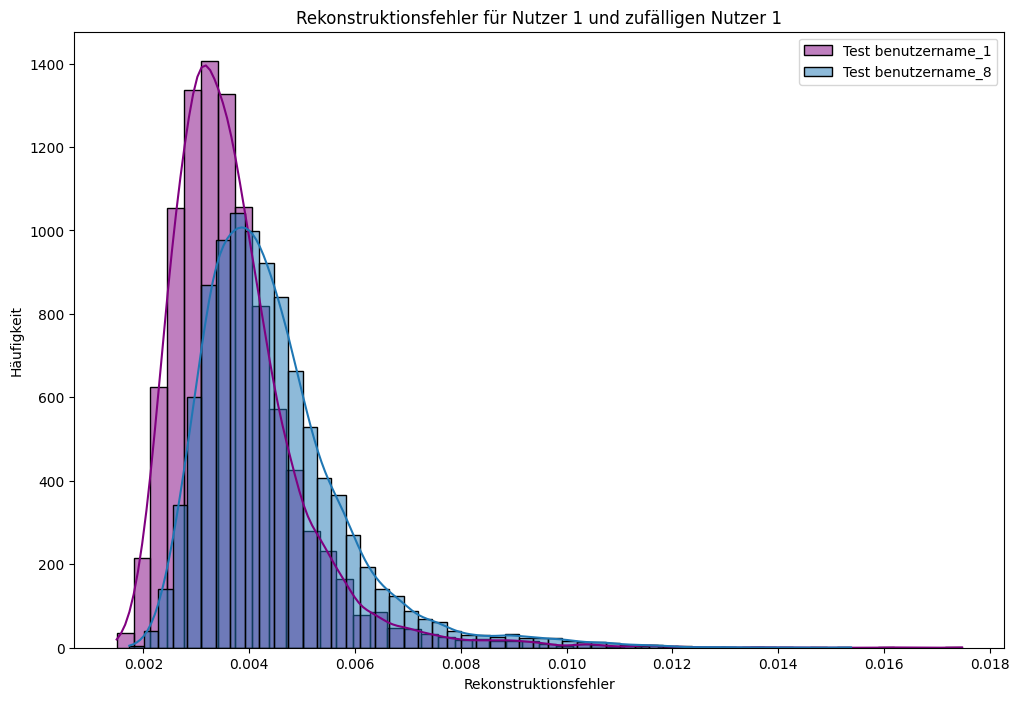

1/1 [==============================] - 0s 13ms/step


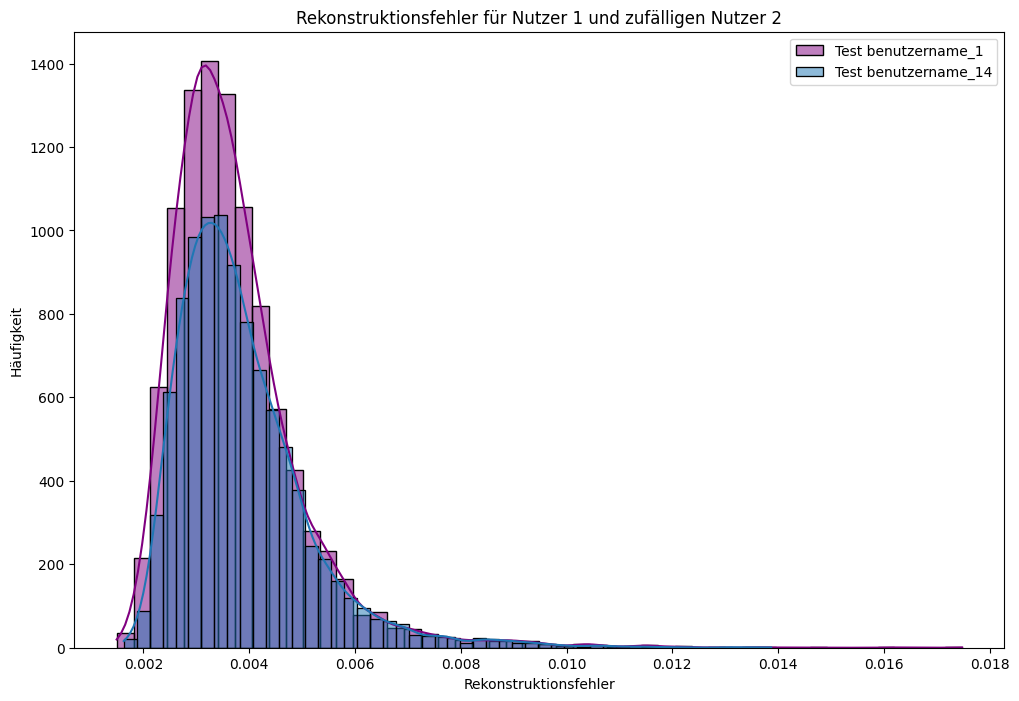

1/1 [==============================] - 0s 13ms/step


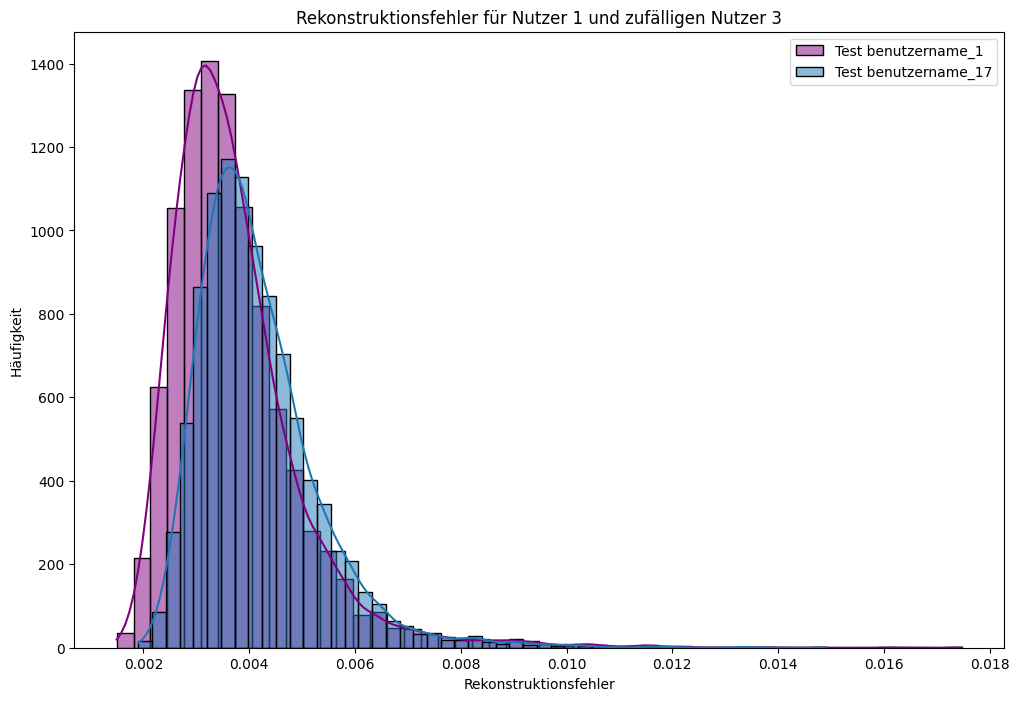

1/1 [==============================] - 0s 13ms/step


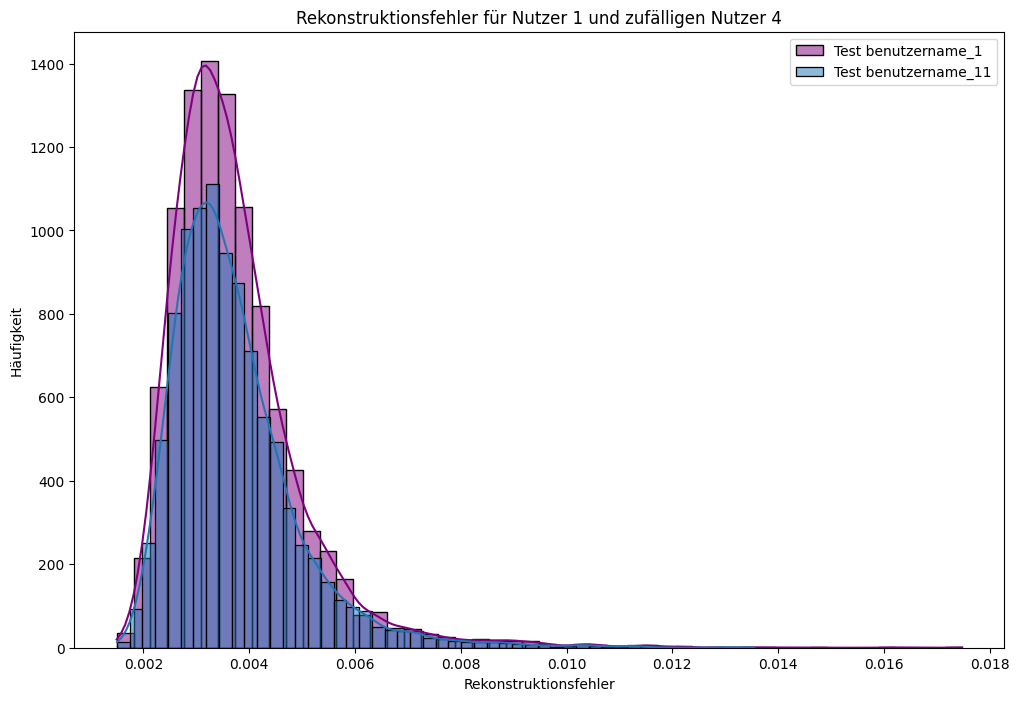

1/1 [==============================] - 0s 13ms/step


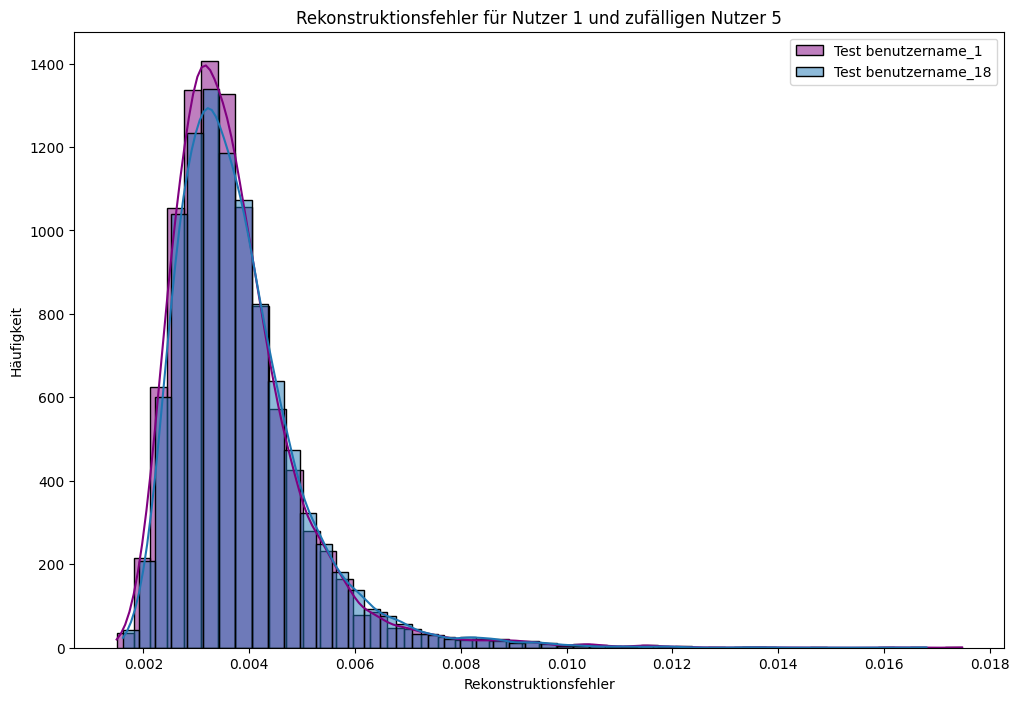

1/1 [==============================] - 0s 13ms/step

Bewertung der Modellleistung:
Durchschnittlicher Rekonstruktionsfehler (Nutzer 1): 0.0037209923382620206
Durchschnittlicher Rekonstruktionsfehler (zufällige Nutzer): 0.004199574142526296

Adaptive Erklärung der Ergebnisse:
Das Modell erkennt Nutzer 1 gut und unterscheidet ihn von anderen Nutzern.
625/625 [==============================] - 1s 1ms/step
Anzahl der zufälligen Samples: 20000
Rekonstruktionsfehler für zufällige Samples: [0.00357652 0.0025752  0.00481737 ... 0.0038717  0.00239568 0.00356337]


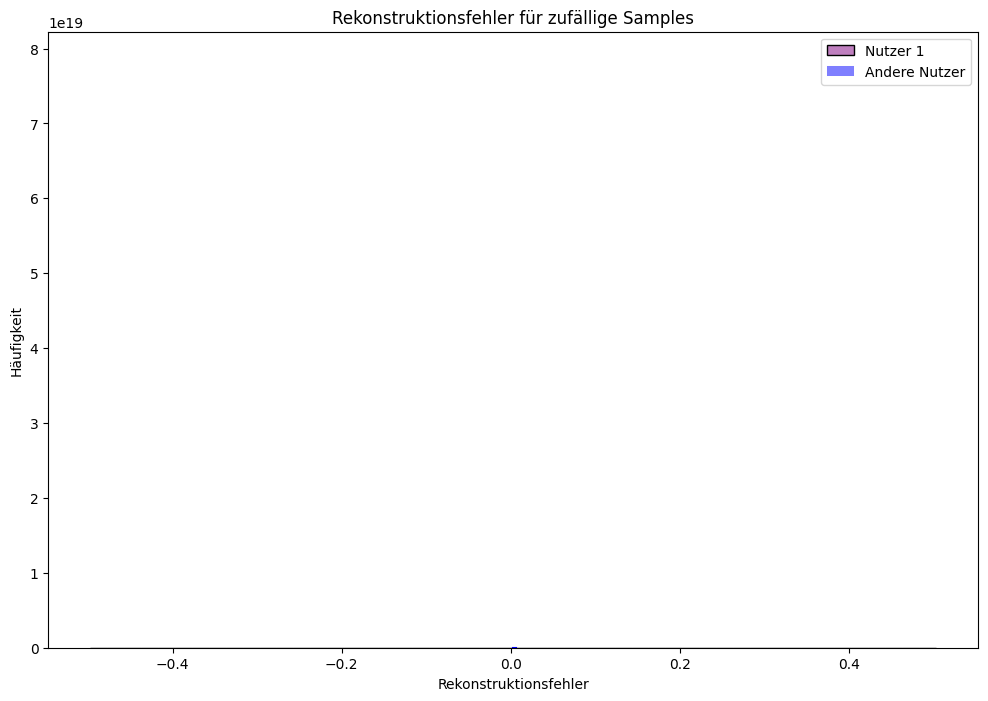


Bewertung der Modellleistung für zufällige Samples:
Durchschnittlicher Rekonstruktionsfehler (Nutzer 1 Samples): 0.0027029076364193582
Durchschnittlicher Rekonstruktionsfehler (Andere Nutzer Samples): 0.0038640997092363434

Adaptive Erklärung der Ergebnisse für zufällige Samples:
Das Modell erkennt zufällige Samples von Nutzer 1 gut und unterscheidet sie von anderen Nutzern.

Vorhersageergebnisse:
True Positives: 1058
True Negatives: 13024
False Positives: 5918
False Negatives: 0
Genauigkeit: 0.7041

Adaptive Erklärung der Vorhersageergebnisse:
Das Modell kann Nutzer 1 einigermaßen gut erkennen, aber es gibt Raum für Verbesserungen.


In [4]:
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Berechnung der Rekonstruktionsfehler
def calculate_reconstruction_error(model, generator):
    reconstruction_errors = []
    for batch in generator:
        X, _ = batch
        reconstructed = model.predict(X)
        reconstruction_error = np.mean(np.square(X - reconstructed), axis=1)
        reconstruction_errors.extend(reconstruction_error)
    return np.array(reconstruction_errors)

# Berechnung der Rekonstruktionsfehler für eine begrenzte Anzahl von Testdaten
def calculate_reconstruction_error_limited(model, generator, limit=10000):
    reconstruction_errors = []
    count = 0
    for batch in generator:
        if count >= limit:
            break
        X, _ = batch
        reconstructed = model.predict(X)
        reconstruction_error = np.mean(np.square(X - reconstructed), axis=1)
        reconstruction_errors.extend(reconstruction_error)
        count += len(X)
    return np.array(reconstruction_errors[:limit])

# Rekonstruktionsfehler für Nutzer 1
user_1_id = user_ids[0]  # Assuming user 1 is the first user in the list
_, _, test_generator_user_1 = user_generators[user_1_id]
reconstruction_error_user_1 = calculate_reconstruction_error_limited(autoencoder, test_generator_user_1, limit=10000)

# Erstellen von 5 Diagrammen mit Nutzer 1 und einem zufälligen anderen Nutzer
for i in range(5):
    random_user_id = random.choice([uid for uid in user_ids if uid != user_1_id])
    _, _, test_generator_random_user = user_generators[random_user_id]
    reconstruction_error_random_user = calculate_reconstruction_error_limited(autoencoder, test_generator_random_user, limit=10000)
    
    plt.figure(figsize=(12, 8))
    sns.histplot(reconstruction_error_user_1, bins=50, kde=True, color='purple', label=f'Test {user_1_id}')
    sns.histplot(reconstruction_error_random_user, bins=50, kde=True, label=f'Test {random_user_id}')
    
    plt.title(f'Rekonstruktionsfehler für Nutzer 1 und zufälligen Nutzer {i+1}')
    plt.xlabel('Rekonstruktionsfehler')
    plt.ylabel('Häufigkeit')
    plt.legend()
    plt.show()

# Bewertung der Modellleistung
mean_user_1_error = np.mean(reconstruction_error_user_1)
mean_random_user_errors = []

for i in range(5):
    random_user_id = random.choice([uid for uid in user_ids if uid != user_1_id])
    _, _, test_generator_random_user = user_generators[random_user_id]
    reconstruction_error_random_user = calculate_reconstruction_error_limited(autoencoder, test_generator_random_user, limit=10000)
    mean_random_user_errors.append(np.mean(reconstruction_error_random_user))

mean_random_user_error = np.mean(mean_random_user_errors)

print("\nBewertung der Modellleistung:")
print(f"Durchschnittlicher Rekonstruktionsfehler (Nutzer 1): {mean_user_1_error}")
print(f"Durchschnittlicher Rekonstruktionsfehler (zufällige Nutzer): {mean_random_user_error}")

# Adaptive Erklärung der Ergebnisse
print("\nAdaptive Erklärung der Ergebnisse:")
if mean_user_1_error < min(mean_random_user_errors):
    print("Das Modell erkennt Nutzer 1 gut und unterscheidet ihn von anderen Nutzern.")
elif mean_user_1_error < np.mean(mean_random_user_errors):
    print("Das Modell erkennt Nutzer 1 einigermaßen gut, aber es gibt Raum für Verbesserungen.")
else:
    print("Das Modell hat Schwierigkeiten, Nutzer 1 von anderen Nutzern zu unterscheiden. Eine weitere Optimierung ist erforderlich.")

# Test mit 10.000 zufälligen Samples pro Nutzer
random_samples = []
random_labels = []

for _ in range(1000 * len(user_ids)):
    random_user_id = random.choice(user_ids)
    _, _, test_generator_random_user = user_generators[random_user_id]
    random_sample = next(iter(test_generator_random_user))[0][0]  # Nimm das erste Sample aus dem Generator
    random_samples.append(random_sample)
    random_labels.append(1 if random_user_id == user_1_id else 0)

random_samples = np.array(random_samples)
reconstruction_errors_random_samples = np.mean(np.square(random_samples - autoencoder.predict(random_samples)), axis=1)

# Debugging-Ausgaben
print(f"Anzahl der zufälligen Samples: {len(random_samples)}")
print(f"Rekonstruktionsfehler für zufällige Samples: {reconstruction_errors_random_samples}")

# Grafische Darstellung der Rekonstruktionsfehler für zufällige Samples
plt.figure(figsize=(12, 8))
sns.histplot(reconstruction_errors_random_samples[np.array(random_labels) == 1], bins=50, kde=True, color='purple', label='Nutzer 1')
sns.histplot(reconstruction_errors_random_samples[np.array(random_labels) == 0], bins=50, kde=True, color='blue', label='Andere Nutzer')

plt.title('Rekonstruktionsfehler für zufällige Samples')
plt.xlabel('Rekonstruktionsfehler')
plt.ylabel('Häufigkeit')
plt.legend()
plt.show()

# Bewertung der Modellleistung für zufällige Samples
mean_error_user_1_samples = np.mean(reconstruction_errors_random_samples[np.array(random_labels) == 1])
mean_error_other_samples = np.mean(reconstruction_errors_random_samples[np.array(random_labels) == 0])

print("\nBewertung der Modellleistung für zufällige Samples:")
print(f"Durchschnittlicher Rekonstruktionsfehler (Nutzer 1 Samples): {mean_error_user_1_samples}")
print(f"Durchschnittlicher Rekonstruktionsfehler (Andere Nutzer Samples): {mean_error_other_samples}")

# Adaptive Erklärung der Ergebnisse für zufällige Samples
print("\nAdaptive Erklärung der Ergebnisse für zufällige Samples:")
if mean_error_user_1_samples < mean_error_other_samples:
    print("Das Modell erkennt zufällige Samples von Nutzer 1 gut und unterscheidet sie von anderen Nutzern.")
else:
    print("Das Modell hat Schwierigkeiten, zufällige Samples von Nutzer 1 von anderen Nutzern zu unterscheiden. Eine weitere Optimierung ist erforderlich.")

# Entscheidung, ob ein Sample als Nutzer 1 erkannt wird
threshold = (mean_error_user_1_samples + mean_error_other_samples) / 2
predictions = reconstruction_errors_random_samples < threshold

# Bewertung der Vorhersagen
true_positives = np.sum((predictions == 1) & (np.array(random_labels) == 1))
true_negatives = np.sum((predictions == 0) & (np.array(random_labels) == 0))
false_positives = np.sum((predictions == 1) & (np.array(random_labels) == 0))
false_negatives = np.sum((predictions == 0) & (np.array(random_labels) == 1))

print("\nVorhersageergebnisse:")
print(f"True Positives: {true_positives}")
print(f"True Negatives: {true_negatives}")
print(f"False Positives: {false_positives}")
print(f"False Negatives: {false_negatives}")

accuracy = (true_positives + true_negatives) / len(predictions)
print(f"Genauigkeit: {accuracy}")

# Adaptive Erklärung der Vorhersageergebnisse
print("\nAdaptive Erklärung der Vorhersageergebnisse:")
if accuracy > 0.8:
    print("Das Modell kann Nutzer 1 gut erkennen.")
elif accuracy > 0.6:
    print("Das Modell kann Nutzer 1 einigermaßen gut erkennen, aber es gibt Raum für Verbesserungen.")
else:
    print("Das Modell hat Schwierigkeiten, Nutzer 1 zu erkennen. Eine weitere Optimierung ist erforderlich.")
    

In [ ]:
import random

# Berechnung der Rekonstruktionsfehler
def calculate_reconstruction_error(model, generator):
    reconstruction_errors = []
    for batch in generator:
        X, _ = batch
        reconstructed = model.predict(X)
        reconstruction_error = np.mean(np.square(X - reconstructed), axis=1)
        reconstruction_errors.extend(reconstruction_error)
    return np.array(reconstruction_errors)

# Berechnung der Rekonstruktionsfehler für eine begrenzte Anzahl von Testdaten
def calculate_reconstruction_error_limited(model, generator, limit=100):
    reconstruction_errors = []
    count = 0
    for batch in generator:
        if count >= limit:
            break
        X, _ = batch
        reconstructed = model.predict(X)
        reconstruction_error = np.mean(np.square(X - reconstructed), axis=1)
        reconstruction_errors.extend(reconstruction_error)
        count += len(X)
    return np.array(reconstruction_errors[:limit])

# Rekonstruktionsfehler für Nutzer 1
user_1_id = user_ids[0]  # Assuming user 1 is the first user in the list
_, _, test_generator_user_1 = user_generators[user_1_id]
reconstruction_error_user_1 = calculate_reconstruction_error_limited(autoencoder, test_generator_user_1, limit=100)

# Erstellen von 5 Diagrammen mit Nutzer 1 und einem zufälligen anderen Nutzer
for i in range(5):
    random_user_id = random.choice([uid for uid in user_ids if uid != user_1_id])
    _, _, test_generator_random_user = user_generators[random_user_id]
    reconstruction_error_random_user = calculate_reconstruction_error_limited(autoencoder, test_generator_random_user, limit=100)
    
    plt.figure(figsize=(12, 8))
    sns.histplot(reconstruction_error_user_1, bins=50, kde=True, color='purple', label=f'Test {user_1_id}')
    sns.histplot(reconstruction_error_random_user, bins=50, kde=True, label=f'Test {random_user_id}')
    
    plt.title(f'Rekonstruktionsfehler für Nutzer 1 und zufälligen Nutzer {i+1}')
    plt.xlabel('Rekonstruktionsfehler')
    plt.ylabel('Häufigkeit')
    plt.legend()
    plt.show()

In [ ]:
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Berechnung der Rekonstruktionsfehler
def calculate_reconstruction_error(model, generator):
    reconstruction_errors = []
    for batch in generator:
        X, _ = batch
        reconstructed = model.predict(X)
        reconstruction_error = np.mean(np.square(X - reconstructed), axis=1)
        reconstruction_errors.extend(reconstruction_error)
    return np.array(reconstruction_errors)

# Berechnung der Rekonstruktionsfehler für eine begrenzte Anzahl von Testdaten
def calculate_reconstruction_error_limited(model, generator, limit=100):
    reconstruction_errors = []
    count = 0
    for batch in generator:
        if count >= limit:
            break
        X, _ = batch
        reconstructed = model.predict(X)
        reconstruction_error = np.mean(np.square(X - reconstructed), axis=1)
        reconstruction_errors.extend(reconstruction_error)
        count += len(X)
    return np.array(reconstruction_errors[:limit])

# Rekonstruktionsfehler für Nutzer 1
user_1_id = user_ids[0]  # Assuming user 1 is the first user in the list
_, _, test_generator_user_1 = user_generators[user_1_id]
reconstruction_error_user_1 = calculate_reconstruction_error_limited(autoencoder, test_generator_user_1, limit=100)

# Erstellen von 5 Diagrammen mit Nutzer 1 und einem zufälligen anderen Nutzer
for i in range(5):
    random_user_id = random.choice([uid for uid in user_ids if uid != user_1_id])
    _, _, test_generator_random_user = user_generators[random_user_id]
    reconstruction_error_random_user = calculate_reconstruction_error_limited(autoencoder, test_generator_random_user, limit=100)
    
    plt.figure(figsize=(12, 8))
    sns.histplot(reconstruction_error_user_1, bins=50, kde=True, color='purple', label=f'Test {user_1_id}')
    sns.histplot(reconstruction_error_random_user, bins=50, kde=True, label=f'Test {random_user_id}')
    
    plt.title(f'Rekonstruktionsfehler für Nutzer 1 und zufälligen Nutzer {i+1}')
    plt.xlabel('Rekonstruktionsfehler')
    plt.ylabel('Häufigkeit')
    plt.legend()
    plt.show()

# Bewertung der Modellleistung
mean_user_1_error = np.mean(reconstruction_error_user_1)
mean_random_user_errors = []

for i in range(5):
    random_user_id = random.choice([uid for uid in user_ids if uid != user_1_id])
    _, _, test_generator_random_user = user_generators[random_user_id]
    reconstruction_error_random_user = calculate_reconstruction_error_limited(autoencoder, test_generator_random_user, limit=100)
    mean_random_user_errors.append(np.mean(reconstruction_error_random_user))

mean_random_user_error = np.mean(mean_random_user_errors)

print("\nBewertung der Modellleistung:")
print(f"Durchschnittlicher Rekonstruktionsfehler (Nutzer 1): {mean_user_1_error}")
print(f"Durchschnittlicher Rekonstruktionsfehler (zufällige Nutzer): {mean_random_user_error}")

# Adaptive Erklärung der Ergebnisse
print("\nAdaptive Erklärung der Ergebnisse:")
if mean_user_1_error < min(mean_random_user_errors):
    print("Das Modell erkennt Nutzer 1 gut und unterscheidet ihn von anderen Nutzern.")
elif mean_user_1_error < np.mean(mean_random_user_errors):
    print("Das Modell erkennt Nutzer 1 einigermaßen gut, aber es gibt Raum für Verbesserungen.")
else:
    print("Das Modell hat Schwierigkeiten, Nutzer 1 von anderen Nutzern zu unterscheiden. Eine weitere Optimierung ist erforderlich.")

# Test mit 100 zufälligen Samples
random_samples = []
random_labels = []

for _ in range(100):
    random_user_id = random.choice(user_ids)
    _, _, test_generator_random_user = user_generators[random_user_id]
    random_sample = next(iter(test_generator_random_user))[0][0]  # Nimm das erste Sample aus dem Generator
    random_samples.append(random_sample)
    random_labels.append(1 if random_user_id == user_1_id else 0)

random_samples = np.array(random_samples)
reconstruction_errors_random_samples = np.mean(np.square(random_samples - autoencoder.predict(random_samples)), axis=1)

# Debugging-Ausgaben
print(f"Anzahl der zufälligen Samples: {len(random_samples)}")
print(f"Rekonstruktionsfehler für zufällige Samples: {reconstruction_errors_random_samples}")

# Grafische Darstellung der Rekonstruktionsfehler für zufällige Samples
plt.figure(figsize=(12, 8))
sns.histplot(reconstruction_errors_random_samples[np.array(random_labels) == 1], bins=50, kde=True, color='purple', label='Nutzer 1')
sns.histplot(reconstruction_errors_random_samples[np.array(random_labels) == 0], bins=50, kde=True, color='blue', label='Andere Nutzer')

plt.title('Rekonstruktionsfehler für zufällige Samples')
plt.xlabel('Rekonstruktionsfehler')
plt.ylabel('Häufigkeit')
plt.legend()
plt.show()

# Bewertung der Modellleistung für zufällige Samples
mean_error_user_1_samples = np.mean(reconstruction_errors_random_samples[np.array(random_labels) == 1])
mean_error_other_samples = np.mean(reconstruction_errors_random_samples[np.array(random_labels) == 0])

print("\nBewertung der Modellleistung für zufällige Samples:")
print(f"Durchschnittlicher Rekonstruktionsfehler (Nutzer 1 Samples): {mean_error_user_1_samples}")
print(f"Durchschnittlicher Rekonstruktionsfehler (Andere Nutzer Samples): {mean_error_other_samples}")

# Adaptive Erklärung der Ergebnisse für zufällige Samples
print("\nAdaptive Erklärung der Ergebnisse für zufällige Samples:")
if mean_error_user_1_samples < mean_error_other_samples:
    print("Das Modell erkennt zufällige Samples von Nutzer 1 gut und unterscheidet sie von anderen Nutzern.")
else:
    print("Das Modell hat Schwierigkeiten, zufällige Samples von Nutzer 1 von anderen Nutzern zu unterscheiden. Eine weitere Optimierung ist erforderlich.")

In [ ]:
import os
import pandas as pd
import pymongo
import matplotlib.pyplot as plt
import seaborn as sns
import base64
from io import BytesIO
from PIL import Image
import numpy as np
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.optimizers import Adam
from PIL import Image
from io import BytesIO

In [2]:
# Verbindung zur Datenbank herstellen und Daten laden
def load_data():
    # Verbindung zur Datenbank herstellen
    mongo_uri = os.getenv('MONGO_URI', 'mongodb://localhost:27017/fingerprintDB')
    client = pymongo.MongoClient(mongo_uri)
    db = client.get_default_database()

    # Daten aus der 'canvassamples'-Collection laden
    canvassamples_collection = db['canvassamples']
    canvassamples_cursor = canvassamples_collection.find()
    canvassamples_data = list(canvassamples_cursor)
    canvassamples_df = pd.DataFrame(canvassamples_data)

    # Daten aus der 'fingerprints'-Collection laden
    fingerprints_collection = db['fingerprints']
    fingerprints_cursor = fingerprints_collection.find()
    fingerprints_data = list(fingerprints_cursor)
    fingerprints_df = pd.DataFrame(fingerprints_data)

    return canvassamples_df, fingerprints_df

# Daten laden
canvassamples_df, fingerprints_df = load_data()

In [ ]:
# Daten zusammenführen
merged_df = pd.merge(canvassamples_df, fingerprints_df, left_on='fingerprintId', right_on='_id', suffixes=('_sample', '_fingerprint'))

# Benutzer-IDs extrahieren
user_ids = merged_df['username'].unique()

# DataFrames für jeden Benutzer erstellen
user_dfs = {user_id: merged_df[merged_df['username'] == user_id] for user_id in user_ids}

# Beispielhafte Anzeige der ersten 5 Zeilen für jeden Benutzer
for user_id, df in user_dfs.items():
    print(f"Erste 5 Zeilen für Benutzer {user_id}:")
    display(df.head())

In [4]:
import numpy as np
import base64
from PIL import Image
from io import BytesIO

def preprocess_samples(samples, target_length):
    processed_samples = []
    for sample in samples:
        if len(sample) > target_length:
            processed_samples.append(sample[:target_length])
        else:
            processed_samples.append(np.pad(sample, (0, target_length - len(sample)), 'constant'))
    return np.array(processed_samples)

def process_sample(base64_str, target_size):
    try:
        image_data = base64.b64decode(base64_str)
        image = Image.open(BytesIO(image_data)).convert('RGB')
        image = image.resize(target_size)
        return np.array(image) / 255.0
    except Exception as e:
        print(f"Fehler beim Dekodieren des Bildes: {e}")
        return None

In [5]:
import base64
from sklearn.model_selection import train_test_split

def split_data(df, target_size):
    # Decode base64 and convert to numpy arrays
    decoded_samples = [process_sample(sample, target_size) for sample in df['sampleData']]
    decoded_samples = [sample for sample in decoded_samples if sample is not None]  # Remove None entries

    # Convert to numpy array and reshape
    X = np.array(decoded_samples)
    X = X.reshape((X.shape[0], -1))  # Flatten for the Dense encoder

    # Split the data
    X_train, X_temp = train_test_split(X, test_size=0.3, random_state=42)
    X_val, X_test = train_test_split(X_temp, test_size=0.33, random_state=42)  # 0.33 * 0.3 ≈ 0.1
    return X_train, X_val, X_test

In [ ]:
import base64
import numpy as np

# Funktion zur Berechnung der Länge eines dekodierten Samples
def decoded_length(sample):
    return len(base64.b64decode(sample))

# Berechnung der Länge der dekodierten Samples
lengths = np.array([decoded_length(sample) for sample in merged_df['sampleData']])

# Bestimmen der maximalen Länge
max_length = lengths.max()

print(f"Maximale Länge der Samples: {max_length}")

In [ ]:
import base64
import numpy as np
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import Sequence
from PIL import Image
from io import BytesIO

def process_sample(base64_str, target_size):
    try:
        image_data = base64.b64decode(base64_str)
        image = Image.open(BytesIO(image_data)).convert('RGB')
        image = image.resize(target_size)
        return np.array(image) / 255.0
    except Exception as e:
        print(f"Fehler beim Dekodieren des Bildes: {e}")
        return None

def split_data_indices(df):
    if len(df) < 3:
        raise ValueError("Nicht genügend Samples zum Aufteilen.")
    indices = df.index.values
    X_train_indices, X_temp_indices = train_test_split(indices, test_size=0.3, random_state=42)
    X_val_indices, X_test_indices = train_test_split(X_temp_indices, test_size=0.3333, random_state=42)
    return X_train_indices, X_val_indices, X_test_indices

def split_data(df, target_size):
    # Decode base64 and convert to numpy arrays
    decoded_samples = [process_sample(sample, target_size) for sample in df['sampleData']]
    decoded_samples = [sample for sample in decoded_samples if sample is not None]  # Remove None entries

    # Convert to numpy array and reshape
    X = np.array(decoded_samples)
    X = X.reshape((X.shape[0], -1))  # Flatten for the Dense encoder

    # Split the data
    X_train, X_temp = train_test_split(X, test_size=0.3, random_state=42)
    X_val, X_test = train_test_split(X_temp, test_size=0.33, random_state=42)  # 0.33 * 0.3 ≈ 0.1
    return X_train, X_val, X_test

class DataGenerator(Sequence):
    def __init__(self, df, indices, target_size, batch_size=32):
        self.df = df
        self.indices = indices
        self.target_size = target_size
        self.batch_size = batch_size

    def __len__(self):
        return int(np.ceil(len(self.indices) / self.batch_size))

    def __getitem__(self, idx):
        batch_indices = self.indices[idx * self.batch_size:(idx + 1) * self.batch_size]
        batch_samples = [process_sample(self.df.at[i, 'sampleData'], self.target_size) for i in batch_indices]
        batch_samples = [sample for sample in batch_samples if sample is not None]  # Remove None entries
        batch_samples = np.array(batch_samples)
        batch_samples = batch_samples.reshape((batch_samples.shape[0], -1))  # Flatten for the Dense encoder
        return batch_samples, batch_samples  # Input und Output sind gleich für Autoencoder

target_size = (64, 64)  # Zielgröße der Bilder

user_generators = {}
for user_id, df in user_dfs.items():
    print(f"Verarbeite Benutzer {user_id}...")
    try:
        X_train_indices, X_val_indices, X_test_indices = split_data_indices(df)
        train_generator = DataGenerator(df, X_train_indices, target_size, batch_size=32)
        val_generator = DataGenerator(df, X_val_indices, target_size, batch_size=32)
        test_generator = DataGenerator(df, X_test_indices, target_size, batch_size=32)
        user_generators[user_id] = (train_generator, val_generator, test_generator)
        print(f"Datenaufteilung für Benutzer {user_id} abgeschlossen.")
    except Exception as e:
        print(f"Fehler bei der Datenaufteilung für Benutzer {user_id}: {e}")
print("Datenaufteilung für alle Benutzer abgeschlossen.")

In [ ]:
# Verzeichnis für Modelle erstellen
model_dir = "Modelle/Autoencoder"
os.makedirs(model_dir, exist_ok=True)

# Beispielhafter Benutzer
example_user_id = next(iter(user_generators))
train_generator, val_generator, test_generator = user_generators[example_user_id]

# Eingabeform
for batch in train_generator:
    input_dim = batch[0].shape[1]
    break

# Modell erstellen
autoencoder = create_autoencoder(input_dim)

# Modell trainieren
autoencoder.fit(
    train_generator,
    epochs=50,
    validation_data=val_generator
)

# Modell speichern
model_path = os.path.join(model_dir, "autoencoder_model.h5")
autoencoder.save(model_path)
print(f"Modell gespeichert unter: {model_path}")

# TEST MODELLE

In [ ]:
import numpy as np
from tensorflow.keras.layers import Input, Conv1D, Conv1DTranspose, Flatten, Dense, Reshape
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

def create_conv_autoencoder(input_shape):
    input_layer = Input(shape=input_shape)

    # Encoder
    x = Conv1D(32, kernel_size=3, activation='relu', padding='same')(input_layer)
    x = Conv1D(16, kernel_size=3, activation='relu', padding='same')(x)
    x = Flatten()(x)
    encoded = Dense(16, activation='relu')(x)

    # Decoder
    x = Dense(np.prod(input_shape), activation='relu')(encoded)
    x = Reshape(input_shape)(x)
    x = Conv1DTranspose(16, kernel_size=3, activation='relu', padding='same')(x)
    x = Conv1DTranspose(32, kernel_size=3, activation='relu', padding='same')(x)
    decoded = Conv1DTranspose(input_shape[1], kernel_size=3, activation='linear', padding='same')(x)

    autoencoder = Model(inputs=input_layer, outputs=decoded)
    autoencoder.compile(optimizer=Adam(learning_rate=0.001), loss='mse')
    return autoencoder

In [ ]:
# Annahme: 'user_generators' enthält die Daten für jeden Benutzer
train_generator, _, _ = user_generators[example_user_id]

# Extrahieren der Trainingsdaten
X_train = []
for batch in train_generator:
    X_batch, _ = batch
    X_train.append(X_batch)
X_train = np.concatenate(X_train, axis=0)

In [ ]:
input_shape = (12288, 1)

autoencoder = create_conv_autoencoder(input_shape)

# Training
autoencoder.fit(X_train, X_train, epochs=50, batch_size=32, shuffle=True)

In [ ]:
# Funktion zur Berechnung der Rekonstruktionsfehler
def calculate_reconstruction_errors(model, data):
    # Reshape der Daten zu (Batch_Size, Steps, Features)
    data_reshaped = np.expand_dims(data, axis=-1)  # Form: (9999, 12288, 1)
    
    # Modellvorhersage
    reconstructed = model.predict(data_reshaped)
    
    return errors

# Berechnung der Rekonstruktionsfehler für alle Benutzer
user_errors = {}
for user_id in user_ids:
    _, _, test_generator = user_generators[user_id]
    X_test = []
    for batch in test_generator:
        X_batch, _ = batch
        X_test.append(X_batch)
    X_test = np.concatenate(X_test, axis=0)  # Form: (9999, 12288)
    
    # Berechnen der Rekonstruktionsfehler mit der angepassten Funktion
    errors = calculate_reconstruction_errors(autoencoder, X_test)
    user_errors[user_id] = errors

In [ ]:
# Konfusionsmatrix darstellen
import seaborn as sns
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Benutzer 1', 'Nicht Benutzer 1'],
            yticklabels=['Benutzer 1', 'Nicht Benutzer 1'])
plt.xlabel('Vorhergesagte Labels')
plt.ylabel('Wahre Labels')
plt.title('Konfusionsmatrix')
plt.show()

# DONE

In [ ]:
# Schwellenwert basierend auf Benutzer 1
threshold = np.mean(user_errors[example_user_id]) + 2 * np.std(user_errors[example_user_id])

# Klassifikation und Evaluierung
true_labels = []
predicted_labels = []

for user_id in user_ids:
    errors = user_errors[user_id]
    predictions = ['Benutzer 1' if e <= threshold else 'Nicht Benutzer 1' for e in errors]
    predicted_labels.extend(predictions)
    labels = ['Benutzer 1' if user_id == example_user_id else 'Nicht Benutzer 1'] * len(errors)
    true_labels.extend(labels)

# Konfusionsmatrix und Bericht
conf_matrix = confusion_matrix(true_labels, predicted_labels, labels=['Benutzer 1', 'Nicht Benutzer 1'])
report = classification_report(true_labels, predicted_labels, target_names=['Benutzer 1', 'Nicht Benutzer 1'])

print('Konfusionsmatrix:')
print(conf_matrix)
print('\nKlassifikationsbericht:')
print(report)

In [ ]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout
from tensorflow.keras.optimizers import Adam

# Beispielhafter Benutzer
example_user_id = next(iter(user_generators))
train_generator, val_generator, test_generator = user_generators[example_user_id]

# Ausgabe der Informationen
print(f"Beispielhafter Benutzer: {example_user_id}")
print(f"Anzahl der Trainingsbatches: {len(train_generator)}")
print(f"Anzahl der Validierungsbatches: {len(val_generator)}")
print(f"Anzahl der Testbatches: {len(test_generator)}")

# Autoencoder-Modell definieren
input_dim = train_generator[0][0].shape[1]
encoding_dim = 64  # Erhöhte Encoding-Dimension

input_layer = Input(shape=(input_dim,))

# Encoder mit mehreren Schichten und Dropout zur Regulierung
encoder = Dense(128, activation="relu")(input_layer)
encoder = Dropout(0.3)(encoder)  # Dropout zur Vermeidung von Overfitting
encoder = Dense(64, activation="relu")(encoder)
encoder = Dense(encoding_dim, activation="relu")(encoder)

# Decoder mit mehreren Schichten
decoder = Dense(64, activation="relu")(encoder)
decoder = Dense(128, activation="relu")(decoder)
decoder = Dense(input_dim, activation="sigmoid")(decoder)

# Autoencoder-Modell erstellen
autoencoder = Model(inputs=input_layer, outputs=decoder)

# Modell kompilieren mit MAE als Verlustfunktion
autoencoder.compile(optimizer=Adam(), loss='mae')

# Modell trainieren
history = autoencoder.fit(
    train_generator,
    epochs=100,  # Erhöhte Anzahl an Epochen für besseres Training
    validation_data=val_generator
)

# Modell bewerten (optional)
test_loss = autoencoder.evaluate(test_generator)
print(f"Testverlust: {test_loss}")

# Optional: Speichern des Modells nach dem Training
autoencoder.save("autoencoder_model.h5")

In [ ]:
# Berechnung der Rekonstruktionsfehler
def calculate_reconstruction_error(model, generator):
    reconstruction_errors = []
    for batch in generator:
        X, _ = batch
        reconstructed = model.predict(X)
        reconstruction_error = np.mean(np.square(X - reconstructed), axis=1)
        reconstruction_errors.extend(reconstruction_error)
    return np.array(reconstruction_errors)

# Rekonstruktionsfehler für den Trainings-, Validierungs- und Test-Satz des Benutzers
reconstruction_error_train = calculate_reconstruction_error(autoencoder, train_generator)
reconstruction_error_val = calculate_reconstruction_error(autoencoder, val_generator)
reconstruction_error_test = calculate_reconstruction_error(autoencoder, test_generator)

# Grafische Darstellung der Ergebnisse für den Beispielbenutzer
plt.figure(figsize=(12, 8))
sns.histplot(reconstruction_error_train, bins=50, kde=True, color='blue', label='Train')
sns.histplot(reconstruction_error_val, bins=50, kde=True, color='green', label='Validation')
sns.histplot(reconstruction_error_test, bins=50, kde=True, color='red', label='Test')

plt.title('Rekonstruktionsfehler für den Beispielbenutzer')
plt.xlabel('Rekonstruktionsfehler')
plt.ylabel('Häufigkeit')
plt.legend()
plt.show()

In [ ]:
import random

# Funktion zur Berechnung der Rekonstruktionsfehler für eine begrenzte Anzahl von Testdaten
def calculate_reconstruction_error_limited(model, generator, limit=100):
    reconstruction_errors = []
    count = 0
    for batch in generator:
        if count >= limit:
            break
        X, _ = batch
        reconstructed = model.predict(X)
        reconstruction_error = np.mean(np.square(X - reconstructed), axis=1)
        reconstruction_errors.extend(reconstruction_error)
        count += len(X)
    return np.array(reconstruction_errors[:limit])

# Rekonstruktionsfehler für die Test-Sätze von 3 zufälligen Benutzern
random_user_errors = {}
sampled_user_ids = random.sample([uid for uid in user_ids if uid != example_user_id], 3)
for other_user_id in sampled_user_ids:
    _, _, test_generator_other = user_generators[other_user_id]
    random_user_errors[other_user_id] = calculate_reconstruction_error_limited(autoencoder, test_generator_other, limit=100)

# Grafische Darstellung der Ergebnisse für 3 zufällige Benutzer
plt.figure(figsize=(12, 8))
for other_user_id, errors in random_user_errors.items():
    sns.histplot(errors, bins=50, kde=True, label=f'Test {other_user_id}')

# Hinzufügen der Rekonstruktionsfehler des Beispielbenutzers zum Vergleich
sns.histplot(reconstruction_error_train, bins=50, kde=True, color='blue', label='Train')
sns.histplot(reconstruction_error_test, bins=50, kde=True, color='red', label=f'Test {example_user_id}')

plt.title('Rekonstruktionsfehler für 3 zufällige Benutzer und den Beispielbenutzer')
plt.xlabel('Rekonstruktionsfehler')
plt.ylabel('Häufigkeit')
plt.legend()
plt.show()

In [ ]:
# Zusammenfassung der Ergebnisse für den Beispielbenutzer
print("Rekonstruktionsfehler für den Trainingssatz:")
print(pd.Series(reconstruction_error_train).describe())

print("Rekonstruktionsfehler für den Validierungssatz:")
print(pd.Series(reconstruction_error_val).describe())

print("Rekonstruktionsfehler für den Testsatz:")
print(pd.Series(reconstruction_error_test).describe())

# Zusammenfassung der Ergebnisse für 3 zufällige Benutzer
for other_user_id, errors in random_user_errors.items():
    print(f"Rekonstruktionsfehler für den Testsatz von Benutzer {other_user_id}:")
    print(pd.Series(errors).describe())

# Bewertung der Modellleistung
mean_train_error = np.mean(reconstruction_error_train)
mean_val_error = np.mean(reconstruction_error_val)
mean_test_error = np.mean(reconstruction_error_test)
mean_other_user_errors = {user_id: np.mean(errors) for user_id, errors in random_user_errors.items()}

print("\nBewertung der Modellleistung:")
print(f"Durchschnittlicher Rekonstruktionsfehler (Train): {mean_train_error}")
print(f"Durchschnittlicher Rekonstruktionsfehler (Validation): {mean_val_error}")
print(f"Durchschnittlicher Rekonstruktionsfehler (Test): {mean_test_error}")

for user_id, mean_error in mean_other_user_errors.items():
    print(f"Durchschnittlicher Rekonstruktionsfehler (Test {user_id}): {mean_error}")

# Adaptive Erklärung der Ergebnisse
print("\nAdaptive Erklärung der Ergebnisse:")
if mean_test_error < min(mean_other_user_errors.values()):
    print("Das Modell erkennt den gleichen Benutzer gut und unterscheidet ihn von anderen Benutzern.")
elif mean_test_error < np.mean(list(mean_other_user_errors.values())):
    print("Das Modell erkennt den gleichen Benutzer einigermaßen gut, aber es gibt Raum für Verbesserungen.")
else:
    print("Das Modell hat Schwierigkeiten, den gleichen Benutzer von anderen Benutzern zu unterscheiden. Eine weitere Optimierung ist erforderlich.")

Testing Model

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# Beispielbenutzer (User 1), für den das Modell trainiert wurde
example_user_id = 'benutzername_1'

# Funktion zur Berechnung der Rekonstruktionsfehler für eine begrenzte Anzahl von Testdaten
def calculate_reconstruction_error_limited(model, generator, limit=100):
    reconstruction_errors = []
    count = 0
    for batch in generator:
        X, _ = batch  # Annahme: batch liefert (Daten, Labels)
        reconstructed = model.predict(X)
        errors = np.mean(np.square(X - reconstructed), axis=1)
        reconstruction_errors.extend(errors)
        count += len(X)
        if count >= limit:
            break
    return np.array(reconstruction_errors[:limit])

# Berechnung der Rekonstruktionsfehler für alle Benutzer
user_errors = {}
for user_id in user_ids:
    _, _, test_generator = user_generators[user_id]
    user_errors[user_id] = calculate_reconstruction_error_limited(autoencoder, test_generator, limit=100)

# Berechnung des Schwellenwerts basierend auf den Fehlern von Benutzer 1
threshold = np.mean(user_errors[example_user_id]) + 2 * np.std(user_errors[example_user_id])
print(f"Berechneter Schwellenwert: {threshold}")

# Klassifikation der Testdaten basierend auf dem Schwellenwert
def classify_errors(errors, threshold):
    return ["Benutzer 1" if error <= threshold else "Nicht Benutzer 1" for error in errors]

# Ergebnisse der Klassifikation für jeden Benutzer
classification_results = {}
for user_id, errors in user_errors.items():
    classification_results[user_id] = classify_errors(errors, threshold)

# Erstellung der wahren und vorhergesagten Labels
true_labels = []
predicted_labels = []
for user_id in user_ids:
    labels = ["Benutzer 1" if user_id == example_user_id else "Nicht Benutzer 1"] * len(user_errors[user_id])
    true_labels.extend(labels)
    predicted_labels.extend(classification_results[user_id])

# Konfusionsmatrix und Klassifikationsbericht erstellen
conf_matrix = confusion_matrix(true_labels, predicted_labels, labels=["Benutzer 1", "Nicht Benutzer 1"])
class_report = classification_report(true_labels, predicted_labels, target_names=["Benutzer 1", "Nicht Benutzer 1"])

print("\nKonfusionsmatrix:")
print(conf_matrix)
print("\nKlassifikationsbericht:")
print(class_report)

# Konfusionsmatrix als Heatmap darstellen
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Benutzer 1", "Nicht Benutzer 1"],
            yticklabels=["Benutzer 1", "Nicht Benutzer 1"])
plt.xlabel('Vorhergesagte Labels')
plt.ylabel('Wahre Labels')
plt.title('Konfusionsmatrix')
plt.show()

# Tabellarische Darstellung der Ergebnisse pro Benutzer
results_table = pd.DataFrame(columns=["Benutzer", "Richtig Positive", "Falsch Positive", "Richtig Negative", "Falsch Negative"])

for user_id in user_ids:
    user_true_labels = ["Benutzer 1" if user_id == example_user_id else "Nicht Benutzer 1"] * len(user_errors[user_id])
    user_predicted_labels = classification_results[user_id]
    
    tp = sum((np.array(user_true_labels) == "Benutzer 1") & (np.array(user_predicted_labels) == "Benutzer 1"))
    fp = sum((np.array(user_true_labels) == "Nicht Benutzer 1") & (np.array(user_predicted_labels) == "Benutzer 1"))
    tn = sum((np.array(user_true_labels) == "Nicht Benutzer 1") & (np.array(user_predicted_labels) == "Nicht Benutzer 1"))
    fn = sum((np.array(user_true_labels) == "Benutzer 1") & (np.array(user_predicted_labels) == "Nicht Benutzer 1"))
    
    results_table = pd.concat([results_table, pd.DataFrame({
        "Benutzer": [user_id],
        "Richtig Positive": [tp],
        "Falsch Positive": [fp],
        "Richtig Negative": [tn],
        "Falsch Negative": [fn]
    })], ignore_index=True)

print("\nKlassifikationsergebnisse pro Benutzer:")
print(results_table)

# Grafische Darstellung der Klassifikationsergebnisse pro Benutzer
results_table_melted = results_table.melt(id_vars='Benutzer', 
                                          value_vars=['Richtig Positive', 'Falsch Positive', 'Richtig Negative', 'Falsch Negative'],
                                          var_name='Klassifikation', value_name='Anzahl')

plt.figure(figsize=(12, 6))
sns.barplot(data=results_table_melted, x='Benutzer', y='Anzahl', hue='Klassifikation')
plt.xticks(rotation=90)
plt.xlabel('Benutzer')
plt.ylabel('Anzahl')
plt.title('Klassifikationsergebnisse pro Benutzer')
plt.legend()
plt.show()

In [ ]:
# Berechnung der Rekonstruktionsfehler
def calculate_reconstruction_error(model, generator):
    reconstruction_errors = []
    for batch in generator:
        X, _ = batch
        reconstructed = model.predict(X)
        reconstruction_error = np.mean(np.square(X - reconstructed), axis=1)
        reconstruction_errors.extend(reconstruction_error)
    return np.array(reconstruction_errors)

# Rekonstruktionsfehler für den Trainings-, Validierungs- und Test-Satz des Benutzers
reconstruction_error_train = calculate_reconstruction_error(autoencoder, train_generator)
reconstruction_error_val = calculate_reconstruction_error(autoencoder, val_generator)
reconstruction_error_test = calculate_reconstruction_error(autoencoder, test_generator)

# Rekonstruktionsfehler für die Test-Sätze anderer Benutzer
other_user_errors = {}
for other_user_id in user_ids:
    if other_user_id != example_user_id:
        _, _, test_generator_other = user_generators[other_user_id]
        other_user_errors[other_user_id] = calculate_reconstruction_error(autoencoder, test_generator_other)

# Grafische Darstellung der Ergebnisse
plt.figure(figsize=(12, 8))
sns.histplot(reconstruction_error_train, bins=50, kde=True, color='blue', label='Train')
sns.histplot(reconstruction_error_val, bins=50, kde=True, color='green', label='Validation')
sns.histplot(reconstruction_error_test, bins=50, kde=True, color='red', label='Test')

for other_user_id, errors in other_user_errors.items():
    sns.histplot(errors, bins=50, kde=True, label=f'Test {other_user_id}')

plt.title('Rekonstruktionsfehler')
plt.xlabel('Rekonstruktionsfehler')
plt.ylabel('Häufigkeit')
plt.legend()
plt.show()